# 05 — Transformer Architectures for Battery SOH Prediction (v3)

## v3 Improvements
- **Cross-battery split** (no data leakage)
- **18 features** per timestep (6 new physics-informed features)

## Models
1. **BatteryGPT** — Nano GPT-style decoder-only Transformer (2 layers, 4 heads, d_model=64)
2. **Temporal Fusion Transformer (TFT)** — Variable selection + interpretable multi-horizon
3. **iTransformer (Vanilla)** — Inverted Transformer (feature-wise attention, TensorFlow/Keras)
4. **Physics-Informed iTransformer** — Dual-head with physics constraint (λ_phy=0.3)

**Training:** Adam + CosineAnnealingLR (PyTorch) / ReduceLROnPlateau (TF), EarlyStopping

In [1]:

import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from src.models.deep.transformer import BatteryGPT, TemporalFusionTransformer
from src.models.deep.lstm import train_loop, mc_dropout_predict, EarlyStopping
from src.evaluation.metrics import regression_metrics, tolerance_accuracy, build_summary_table
from src.utils.plotting import (
    plot_training_curves, plot_actual_vs_predicted, plot_residuals,
    plot_model_comparison_bars, save_fig,
)
from src.utils.config import (
    ARTIFACTS_DIR, FIGURES_DIR, MODELS_DIR,
    get_version_paths, ensure_version_dirs,
    WINDOW_SIZE, BATCH_SIZE, MAX_EPOCHS, EARLY_STOP_PATIENCE,
    TRANSFORMER_D_MODEL, TRANSFORMER_NHEAD, TRANSFORMER_LAYERS, LEARNING_RATE, DROPOUT,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
plt.style.use("seaborn-v0_8-whitegrid")

# v3 paths
v3 = get_version_paths('v3')
ensure_version_dirs('v3')

Device: cuda


{'root': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3'),
 'models_classical': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/models/classical'),
 'models_deep': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/models/deep'),
 'models_ensemble': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/models/ensemble'),
 'scalers': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/scalers'),
 'figures': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/figures'),
 'results': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/results'),
 'logs': WindowsPath('E:/VIT/aiBatteryLifecycle/artifacts/v3/logs')}

## 1. Load Sequence Data

In [2]:
V3_FEATURES = v3["root"] / "features"
data = np.load(str(V3_FEATURES / "battery_sequences.npz"), allow_pickle=True)
X_multi = data["X_multi"]
y_multi = data["y_multi"]
bids = data["bids_multi"]

print(f"Sequences: X={X_multi.shape}, y={y_multi.shape}")

# ── v3 FIX: Cross-battery grouped split ──
unique_bids = np.unique(bids)
rng = np.random.RandomState(42)
shuffled = unique_bids.copy()
rng.shuffle(shuffled)
n_train = max(1, int(len(shuffled) * 0.8))
train_bats = set(shuffled[:n_train])
test_bats = set(shuffled[n_train:])

train_mask = np.isin(bids, list(train_bats))
test_mask = np.isin(bids, list(test_bats))

X_train, y_train = X_multi[train_mask], y_multi[train_mask]
X_test, y_test = X_multi[test_mask], y_multi[test_mask]

# Normalize
from sklearn.preprocessing import StandardScaler
n_samples, seq_len, n_feat = X_train.shape
scaler = StandardScaler().fit(X_train.reshape(-1, n_feat))
X_train = scaler.transform(X_train.reshape(-1, n_feat)).reshape(n_samples, seq_len, n_feat)
X_test = scaler.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape[0], seq_len, n_feat)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Features: {n_feat}")
print(f"Train batteries: {sorted(train_bats)}")
print(f"Test batteries:  {sorted(test_bats)}")
print(f"Overlap: {train_bats & test_bats if train_bats & test_bats else 'NONE ✓'}")

Sequences: X=(1734, 32, 18), y=(1734,)
Train: 1444 | Test: 290 | Features: 18
Train batteries: [np.str_('B0005'), np.str_('B0006'), np.str_('B0007'), np.str_('B0018'), np.str_('B0029'), np.str_('B0030'), np.str_('B0033'), np.str_('B0034'), np.str_('B0038'), np.str_('B0039'), np.str_('B0040'), np.str_('B0042'), np.str_('B0043'), np.str_('B0044'), np.str_('B0045'), np.str_('B0048'), np.str_('B0053'), np.str_('B0054'), np.str_('B0055'), np.str_('B0056')]
Test batteries:  [np.str_('B0031'), np.str_('B0032'), np.str_('B0036'), np.str_('B0041'), np.str_('B0046'), np.str_('B0047')]
Overlap: NONE ✓


## 2. BatteryGPT (Nano Transformer)

In [3]:
batterygpt = BatteryGPT(
    input_dim=n_feat, d_model=TRANSFORMER_D_MODEL,
    n_heads=TRANSFORMER_NHEAD, n_layers=TRANSFORMER_LAYERS,
    dropout=DROPOUT, max_len=WINDOW_SIZE * 2,
)
print(f"BatteryGPT params: {sum(p.numel() for p in batterygpt.parameters()):,}")

hist_bgpt = train_loop(
    batterygpt, train_loader, val_loader,
    max_epochs=MAX_EPOCHS, lr=LEARNING_RATE,
    patience=EARLY_STOP_PATIENCE, device=device, grad_clip=1.0,
)
print(f"Best epoch: {hist_bgpt['best_epoch']} / {hist_bgpt['epochs_trained']}")

batterygpt.eval()
with torch.no_grad():
    y_pred_bgpt = batterygpt(X_test_t.to(device)).cpu().numpy()
m_bgpt = regression_metrics(y_test, y_pred_bgpt)
m_bgpt["tol_2pct"] = tolerance_accuracy(y_test, y_pred_bgpt, 2.0)
print(f"MAE={m_bgpt['MAE']:.4f}  R²={m_bgpt['R2']:.4f}  Tol.Acc={m_bgpt['tol_2pct']:.2%}")
torch.save(batterygpt.state_dict(), str(v3["models_deep"] / "batterygpt.pt"))

BatteryGPT params: 101,249
Best epoch: 12 / 32
MAE=9.1768  R²=0.6333  Tol.Acc=20.69%


## 3. Temporal Fusion Transformer (TFT)

In [4]:
tft = TemporalFusionTransformer(
    n_features=n_feat, d_model=TRANSFORMER_D_MODEL,
    n_heads=TRANSFORMER_NHEAD, n_layers=max(1, TRANSFORMER_LAYERS - 1),
    dropout=DROPOUT,
)
print(f"TFT params: {sum(p.numel() for p in tft.parameters()):,}")

hist_tft = train_loop(
    tft, train_loader, val_loader,
    max_epochs=MAX_EPOCHS, lr=LEARNING_RATE,
    patience=EARLY_STOP_PATIENCE, device=device, grad_clip=1.0,
)

tft.eval()
with torch.no_grad():
    y_pred_tft = tft(X_test_t.to(device)).cpu().numpy()
m_tft = regression_metrics(y_test, y_pred_tft)
m_tft["tol_2pct"] = tolerance_accuracy(y_test, y_pred_tft, 2.0)
print(f"MAE={m_tft['MAE']:.4f}  R²={m_tft['R2']:.4f}  Tol.Acc={m_tft['tol_2pct']:.2%}")
torch.save(tft.state_dict(), str(v3["models_deep"] / "tft.pt"))

TFT params: 1,800,403
MAE=3.8832  R²=0.8751  Tol.Acc=36.90%


## 4. iTransformer (TensorFlow/Keras)
Inverted attention — attends across *features* instead of time steps, then aggregates temporally.

In [5]:
import tensorflow as tf
from src.models.deep.itransformer import build_itransformer, build_physics_itransformer

print(f"TensorFlow: {tf.__version__}")

# Build vanilla iTransformer
itrans = build_itransformer(
    seq_len=seq_len, n_features=n_feat,
    d_model=TRANSFORMER_D_MODEL, n_heads=TRANSFORMER_NHEAD,
    n_blocks=TRANSFORMER_LAYERS, dropout=DROPOUT,
)
itrans.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
               loss="mse", metrics=["mae"])
itrans.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=EARLY_STOP_PATIENCE, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=10),
]
hist_itrans = itrans.fit(
    X_train, y_train, validation_data=(X_test, y_test),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks, verbose=1,
)

y_pred_it = itrans.predict(X_test, verbose=0).flatten()
m_it = regression_metrics(y_test, y_pred_it)
m_it["tol_2pct"] = tolerance_accuracy(y_test, y_pred_it, 2.0)
print(f"iTransformer — MAE={m_it['MAE']:.4f}  R²={m_it['R2']:.4f}  Tol.Acc={m_it['tol_2pct']:.2%}")
itrans.save(str(v3["models_deep"] / "itransformer.keras"))

TensorFlow: 2.20.0



Model: "iTransformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_seq (InputLayer)          │ (None, 32, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_proj (Dense)              │ (None, 32, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feat_mha_0 (FeatureWiseMHA)     │ (None, 32, 64)         │         8,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_mha_0 (TokenWiseMHA)      │ (None, 32, 64)         │        16,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_ff_0 (Conv1DFeedForward)   │ (None, 32, 64)         │        33,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feat_mha_1 (FeatureWiseMHA)     │ (None, 32, 64)         │         8,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_mha_1 (TokenWiseMHA)      │ (None, 32, 64)         │        16,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_ff_1 (Conv1DFeedForward)   │ (None, 32, 64)         │        33,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_drop (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ soh_output (Dense)              │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,593 (494.50 KB)

 Trainable params: 126,593 (494.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 2924.1689 - mae: 50.0069 - val_loss: 1631.2758 - val_mae: 37.8781 - learning_rate: 0.0010
Epoch 2/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 761.7496 - mae: 23.1666 - val_loss: 378.3496 - val_mae: 16.2941 - learning_rate: 0.0010
Epoch 3/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 459.1406 - mae: 15.7417 - val_loss: 244.8427 - val_mae: 13.3675 - learning_rate: 0.0010
Epoch 4/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 179.1531 - mae: 9.6085 - val_loss: 161.4709 - val_mae: 9.4961 - learning_rate: 0.0010
Epoch 5/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 104.1442 - mae: 7.4661 - val_loss: 164.4205 - val_mae: 9.2962 - learning_rate: 0.0010
Epoch 6/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 86.1342 - mae: 6.5735 - val_loss: 196.2683 - val_mae: 10.5688 - learning_rate: 0.0010
Epoch 7/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 70.0290 - mae: 5.9279 - val_loss: 213.1279 - val_mae: 10

## 5. Physics-Informed iTransformer
Dual-head model with auxiliary physics branch predicting ΔQ (capacity fade slope).
Joint loss = MSE_soh + λ_phy × MSE_physics

In [6]:
phys_itrans = build_physics_itransformer(
    seq_len=seq_len, n_features=n_feat,
    d_model=TRANSFORMER_D_MODEL, n_heads=TRANSFORMER_NHEAD,
    n_blocks=TRANSFORMER_LAYERS, dropout=DROPOUT, lambda_phy=0.3,
)
phys_itrans.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss={"soh_ml": "mse", "soh_phy": "mse"},
    loss_weights={"soh_ml": 1.0, "soh_phy": 0.3},
    metrics={"soh_ml": "mae"},
)
phys_itrans.summary()

phys_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_soh_ml_loss", patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True, verbose=1, mode="min",
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_soh_ml_loss", factor=0.5, patience=10, verbose=1, mode="min",
    ),
]

delta_q_train = np.gradient(y_train)
delta_q_test = np.gradient(y_test)

hist_phys = phys_itrans.fit(
    X_train, {"soh_ml": y_train, "soh_phy": delta_q_train},
    validation_data=(X_test, {"soh_ml": y_test, "soh_phy": delta_q_test}),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, callbacks=phys_callbacks, verbose=1,
)

y_pred_phys = phys_itrans.predict(X_test, verbose=0)
if isinstance(y_pred_phys, (list, tuple)):
    y_pred_phys_soh = y_pred_phys[0].flatten()
else:
    y_pred_phys_soh = y_pred_phys.flatten()

m_phys = regression_metrics(y_test, y_pred_phys_soh)
m_phys["tol_2pct"] = tolerance_accuracy(y_test, y_pred_phys_soh, 2.0)
print(f"Physics iTransformer — MAE={m_phys['MAE']:.4f}  R²={m_phys['R2']:.4f}  Tol.Acc={m_phys['tol_2pct']:.2%}")
phys_itrans.save(str(v3["models_deep"] / "physics_itransformer.keras"))

Model: "PhysicsInformed_iTransformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_seq           │ (None, 32, 18)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ml_proj (Dense)     │ (None, 32, 64)    │      1,216 │ input_seq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ml_feat_0           │ (None, 32, 64)    │      8,480 │ ml_proj[0][0]     │
│ (FeatureWiseMHA)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ml_token_0          │ (None, 32, 64)    │     16,768 │ ml_feat_0[0][0]   │
│ (TokenWiseMHA)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ml_ff_0             │ (None, 32, 64)    │     33,216 │ ml_token_0[0][0]  │
│ (Conv1DFeedForward) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ml_feat_1           │ (None, 32, 64)    │      8,480 │ ml_ff_0[0][0]     │
│ (FeatureWiseMHA)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ml_token_1          │ (None, 32, 64)    │     16,768 │ ml_feat_1[0][0]   │
│ (TokenWiseMHA)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ml_ff_1             │ (None, 32, 64)    │     33,216 │ ml_token_1[0][0]  │
│ (Conv1DFeedForward) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ abs_cum_current     │ (None, 32, 1)     │          0 │ input_seq[0][0]   │
│ (AbsCumCurrentLaye… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ml_gap              │ (None, 64)        │          0 │ ml_ff_1[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phy_gap             │ (None, 1)         │          0 │ abs_cum_current[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ml_fc (Dense)       │ (None, 128)       │      8,320 │ ml_gap[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phy_fc1 (Dense)     │ (None, 64)        │        128 │ phy_gap[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 128)       │          0 │ ml_fc[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phy_fc2 (Dense)     │ (None, 32)        │      2,080 │ phy_fc1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ soh_ml (Dense)      │ (None, 1)         │        129 │ dropout_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ soh_phy (Dense)     │ (None, 1)         │         33 │ phy_fc2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 128,834 (503.26 KB)

 Trainable params: 128,834 (503.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 3075.8665 - soh_ml_loss: 3058.0813 - soh_ml_mae: 51.4666 - soh_phy_loss: 17.7663 - val_loss: 1852.9209 - val_soh_ml_loss: 1729.8655 - val_soh_ml_mae: 40.5908 - val_soh_phy_loss: 17.6934 - learning_rate: 0.0010
Epoch 2/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 806.3591 - soh_ml_loss: 787.4955 - soh_ml_mae: 23.8750 - soh_phy_loss: 17.6194 - val_loss: 379.7027 - val_soh_ml_loss: 352.0459 - val_soh_ml_mae: 16.0668 - val_soh_phy_loss: 17.8094 - learning_rate: 0.0010
Epoch 3/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 452.2339 - soh_ml_loss: 441.5277 - soh_ml_mae: 15.3852 - soh_phy_loss: 17.5699 - val_loss: 494.9955 - val_soh_ml_loss: 459.6871 - val_soh_ml_mae: 17.8511 - val_soh_phy_loss: 17.8513 - learning_rate: 0.0010
Epoch 4/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 209.8244 - soh_ml_loss: 205.4814 - soh_ml_mae: 10.3365 - soh_phy_loss: 17.4943 - val_loss: 438.8573 - val_soh_ml_loss: 414.9396 - val_soh_

## 6. Training Curves & Comparison

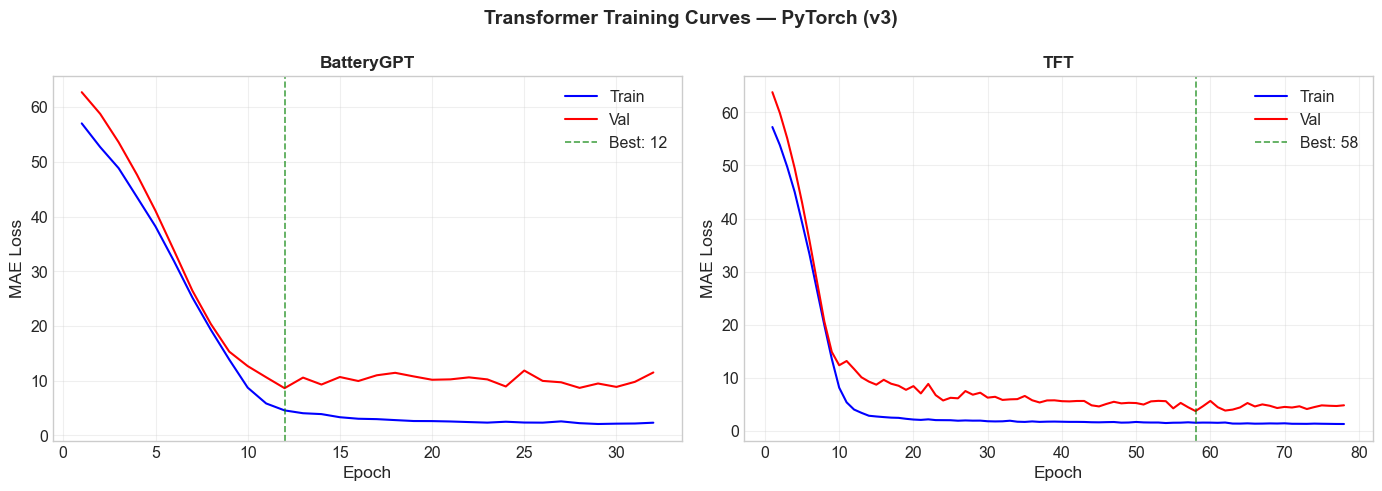

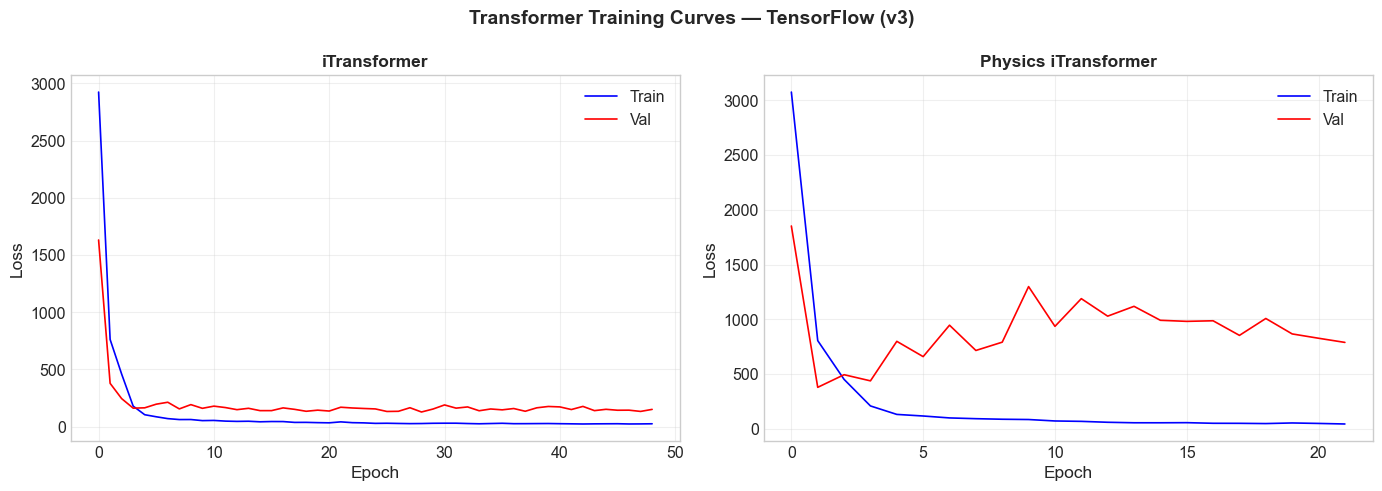

In [7]:
# PyTorch training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, hist) in zip(axes, [("BatteryGPT", hist_bgpt), ("TFT", hist_tft)]):
    epochs = range(1, len(hist["train_losses"]) + 1)
    ax.plot(epochs, hist["train_losses"], "b-", linewidth=1.5, label="Train")
    ax.plot(epochs, hist["val_losses"], "r-", linewidth=1.5, label="Val")
    ax.axvline(x=hist["best_epoch"], color="green", linestyle="--", alpha=0.7, label=f"Best: {hist['best_epoch']}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MAE Loss")
    ax.set_title(name, fontweight="bold"); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle("Transformer Training Curves — PyTorch (v3)", fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig(fig, "v3_transformer_pt_training_curves", directory=v3["figures"]); plt.show()

# Keras training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, hist) in zip(axes, [("iTransformer", hist_itrans), ("Physics iTransformer", hist_phys)]):
    ax.plot(hist.history["loss"], "b-", label="Train")
    ax.plot(hist.history["val_loss"], "r-", label="Val")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title(name, fontweight="bold"); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle("Transformer Training Curves — TensorFlow (v3)", fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig(fig, "v3_transformer_tf_training_curves", directory=v3["figures"]); plt.show()

## 7. Summary Table

In [8]:
all_results = {
    "BatteryGPT": m_bgpt,
    "TFT": m_tft,
    "iTransformer": m_it,
    "Physics iTransformer": m_phys,
}
summary = build_summary_table(all_results).sort_values("R2", ascending=False)
display(summary.round(4))
summary.to_csv(v3["results"] / "v3_transformer_soh_results.csv")

# v3: save raw predictions for CED in NB09
np.savez_compressed(
    str(v3["results"] / "v3_transformer_predictions.npz"),
    y_test=y_test,
    BatteryGPT=y_pred_bgpt,
    TFT=y_pred_tft,
    iTransformer=y_pred_it,
    Physics_iTransformer=y_pred_phys_soh,
)

print("Saved results + raw predictions to v3")
print(f"\nBest: {summary.index[0]} — R² = {summary.iloc[0]['R2']:.4f}, MAE = {summary.iloc[0]['MAE']:.4f}")

,MAE,MSE,RMSE,R2,MAPE,tol_2pct
model,,,,,,
TFT,3.8832,46.0483,6.7859,0.8751,25.3429,0.3690
iTransformer,7.6918,127.9456,11.3113,0.6531,14.6590,0.1966
BatteryGPT,9.1768,135.2250,11.6286,0.6333,14.4997,0.2069
Physics iTransformer,16.0668,373.8231,19.3345,-0.0137,116.1879,0.0000


Saved results + raw predictions to v3

Best: TFT — R² = 0.8751, MAE = 3.8832
